# Polish & End-to-End Testing

---

## What Are We Doing Today?

We have a working vehicle counter and speed estimator from Days 1 and 2.
Today we:
1. Run the full pipeline on test videos and find where it fails
2. Handle common edge cases (night, rain, overlapping, stopped vehicles)
3. Tune each parameter with a systematic approach
4. Add a performance profiler (FPS measurement)
5. Write a clean configuration file so settings are easy to change

## Edge Cases We Need to Handle

| Problem | Symptom | Fix |
|---------|---------|-----|
| Shadows | Ghost vehicles | Increase varThreshold or use detectShadows=True |
| Vehicles touching | One big blob, undercounting | Reduce dilation iterations, use watershed |
| Slow/stopped vehicle | Gets absorbed into background | Increase MOG2 history |
| Night scene | Headlights cause blobs | ROI masking + higher threshold |
| Camera shake | Whole frame flickers as foreground | Increase varThreshold |
| Small vehicles (motorcycles) | Miss them | Lower MIN_CONTOUR_AREA |
| Large vehicles (trucks) | Split into multiple blobs | Larger dilation kernel |

---
# Part 1: Parameter Tuning Guide

## How to Approach Tuning

Never tune all parameters at once. Change one at a time and observe the effect.

## Parameter Map

```
varThreshold (MOG2)
  ↑ increase → less sensitive → fewer false positives (noise, shadows)
  ↓ decrease → more sensitive → catches motorcycles, but more noise

history (MOG2)
  ↑ increase → slower background update → stopped vehicles stay detected longer
  ↓ decrease → faster adaptation → handles day/night transitions better

kernel size (morphology)
  ↑ larger → merges more blobs → good for trucks, risky for touching vehicles
  ↓ smaller → preserves separation → good for counting touching vehicles

dilation iterations
  ↑ more → fills more gaps in vehicle body
  ↓ fewer → keeps vehicles more separate

MIN_CONTOUR_AREA
  ↑ increase → ignores small vehicles (motorcycles, cyclists)
  ↓ decrease → catches everything including noise

max_distance (tracker)
  ↑ increase → handles fast vehicles but may swap IDs at crossings
  ↓ decrease → more reliable IDs but may lose slow/stopped vehicles

max_disappeared (tracker)
  ↑ increase → handles longer occlusions under bridges, by trucks
  ↓ decrease → removes stale tracks faster, avoids ghost counting
```

Training all subtractors...


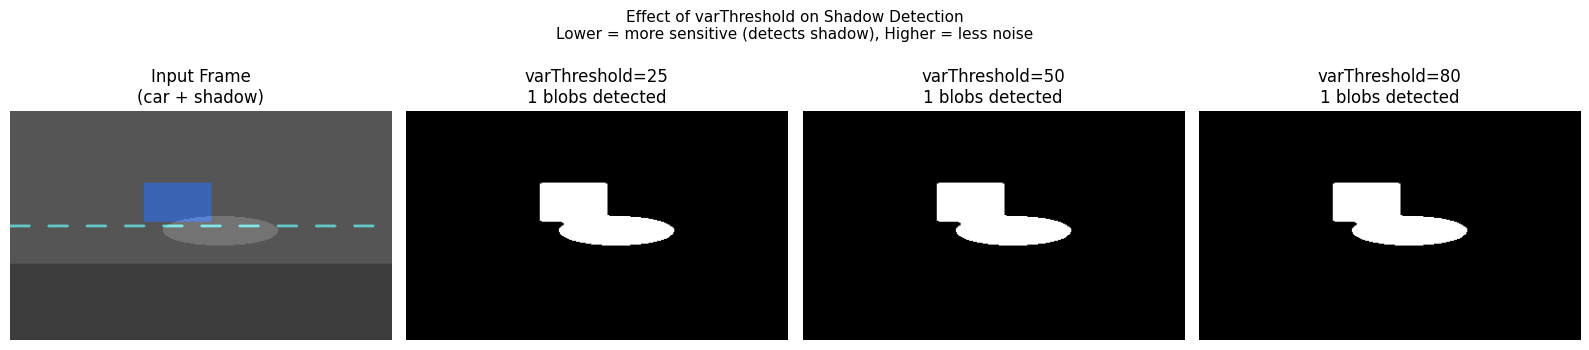


With varThreshold=25: shadow detected as separate blob (false positive)
With varThreshold=80: shadow mostly ignored, but may miss small vehicles


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import time

# ── Interactive parameter comparison ──────────────────────────────────────
# Shows how different varThreshold values affect the mask quality

def make_test_frame(idx, h=240, w=400, add_shadow=True):
    frame = np.ones((h, w, 3), dtype=np.uint8) * 85
    frame[160:h, :] = (60, 60, 60)
    for x in range(0, w, 40):
        cv2.line(frame, (x, 120), (x+20, 120), (200, 200, 100), 2)
    if 20 <= idx < 100:
        x = -60 + (idx - 20) * 5
        cv2.rectangle(frame, (x, 75), (x+70, 115), (180, 100, 60), -1)
        if add_shadow:
            # Add a shadow blob slightly offset from the car
            shadow = np.zeros_like(frame)
            cv2.ellipse(shadow, (x+80, 125), (60, 15), 0, 0, 360, (60,60,60), -1)
            frame = cv2.addWeighted(frame, 1.0, shadow, 0.5, 0)
    return frame

# Train three separate subtractors with different thresholds
thresholds = [25, 50, 80]
subtractors = [
    cv2.createBackgroundSubtractorMOG2(history=200, varThreshold=t, detectShadows=True)
    for t in thresholds
]

kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5,5))

print('Training all subtractors...')
for i in range(30):
    f = make_test_frame(0)
    for sub in subtractors:
        sub.apply(f)

# Test frame with shadow
test = make_test_frame(60, add_shadow=True)
masks = []
for sub in subtractors:
    raw = sub.apply(test)
    _, fg = cv2.threshold(raw, 200, 255, cv2.THRESH_BINARY)
    fg = cv2.morphologyEx(fg, cv2.MORPH_OPEN,  kernel)
    fg = cv2.morphologyEx(fg, cv2.MORPH_CLOSE, kernel)
    masks.append(fg)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(cv2.cvtColor(test, cv2.COLOR_BGR2RGB))
axes[0].set_title('Input Frame\n(car + shadow)')
for ax, mask, t in zip(axes[1:], masks, thresholds):
    cnts, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    n_blobs = len([c for c in cnts if cv2.contourArea(c) > 200])
    ax.imshow(mask, cmap='gray')
    ax.set_title(f'varThreshold={t}\n{n_blobs} blobs detected')
for ax in axes: ax.axis('off')
plt.suptitle('Effect of varThreshold on Shadow Detection\n'
             'Lower = more sensitive (detects shadow), Higher = less noise', fontsize=11)
plt.tight_layout()
plt.savefig('threshold_comparison.png', dpi=100)
plt.show()
print('\nWith varThreshold=25: shadow detected as separate blob (false positive)')
print('With varThreshold=80: shadow mostly ignored, but may miss small vehicles')

---
# Part 2: Edge Case — Overlapping / Touching Vehicles

## The Problem

When two vehicles drive very close together, their foreground blobs merge into one.
The counter sees one blob but two vehicles passed — **undercounting**.

## Three Solutions

**Solution 1: Reduce dilation (simple)**
Less dilation = blobs stay smaller = less likely to merge.
Trade-off: gaps inside individual vehicles may not get filled.

**Solution 2: Check blob area (simple)**
If a blob is more than 1.5x the typical single-vehicle area, it might be two vehicles.
```python
expected_area = 4000   # typical single vehicle area in pixels
if contour_area > expected_area * 1.5:
    n_vehicles = round(contour_area / expected_area)
    count += n_vehicles   # estimate number of vehicles in the blob
```

**Solution 3: Watershed segmentation (advanced)**
OpenCV Watershed can split a merged blob into separate regions using distance transform.
```python
dist = cv2.distanceTransform(fg, cv2.DIST_L2, 5)
_, sure_fg = cv2.threshold(dist, 0.5 * dist.max(), 255, 0)
# Use watershed markers to split merged vehicles
```

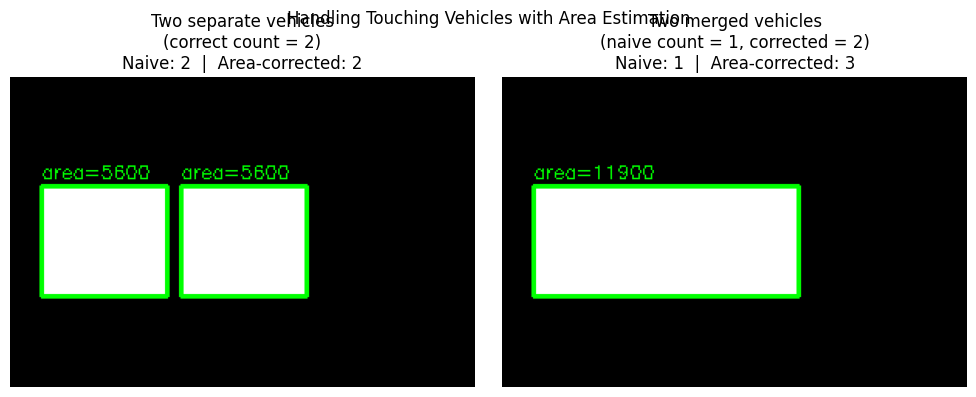

In [2]:
import cv2, numpy as np, matplotlib.pyplot as plt

# ── Demonstrate blob area estimation for touching vehicles ─────────────────

# Create a mask with two vehicle blobs touching
mask = np.zeros((200, 300), dtype=np.uint8)

# Two separate vehicles
cv2.rectangle(mask, (20, 70), (100, 140), 255, -1)
cv2.rectangle(mask, (110, 70), (190, 140), 255, -1)

# Same two vehicles touching / merged
merged_mask = np.zeros((200, 300), dtype=np.uint8)
cv2.rectangle(merged_mask, (20, 70), (190, 140), 255, -1)  # one big blob

EXPECTED_AREA = 4000  # typical single vehicle area

def count_vehicles_in_blob(contour, expected_area):
    area = cv2.contourArea(contour)
    return max(1, round(area / expected_area))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, m, title in [
    (axes[0], mask, 'Two separate vehicles\n(correct count = 2)'),
    (axes[1], merged_mask, 'Two merged vehicles\n(naive count = 1, corrected = 2)'),
]:
    display = cv2.cvtColor(m, cv2.COLOR_GRAY2BGR)
    cnts, _ = cv2.findContours(m, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    naive_count     = len(cnts)
    corrected_count = sum(count_vehicles_in_blob(c, EXPECTED_AREA) for c in cnts)
    for cnt in cnts:
        x,y,w,h = cv2.boundingRect(cnt)
        cv2.rectangle(display,(x,y),(x+w,y+h),(0,255,0),2)
        area = cv2.contourArea(cnt)
        cv2.putText(display, f'area={area:.0f}', (x,y-5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0,255,0), 1)
    ax.imshow(cv2.cvtColor(display, cv2.COLOR_BGR2RGB))
    ax.set_title(f'{title}\nNaive: {naive_count}  |  Area-corrected: {corrected_count}')
    ax.axis('off')

plt.suptitle('Handling Touching Vehicles with Area Estimation', fontsize=12)
plt.tight_layout()
plt.savefig('touching_vehicles.png', dpi=100)
plt.show()

---
# Part 3: Performance Profiling (FPS Measurement)

## Why Measure FPS?

A vehicle counter is useless if it runs at 3 FPS on a 25 FPS camera — it misses most frames.
We profile each step to find which one is the bottleneck.

## Profiling Each Pipeline Stage

```python
import time

t0 = time.perf_counter()
raw_mask = bg_sub.apply(frame)           # BG subtraction
t1 = time.perf_counter()
fg = clean_mask(raw_mask, kernel)         # Morphology
t2 = time.perf_counter()
dets = find_contours(fg, MIN_AREA)        # Contours
t3 = time.perf_counter()
tracks = tracker.update(dets)             # Kalman tracking
t4 = time.perf_counter()

print(f'BG sub:   {(t1-t0)*1000:.1f} ms')
print(f'Morphol:  {(t2-t1)*1000:.1f} ms')
print(f'Contours: {(t3-t2)*1000:.1f} ms')
print(f'Tracking: {(t4-t3)*1000:.1f} ms')
```

## Common Speed-Ups

| Bottleneck | Fix |
|------------|-----|
| BG subtraction slow | Resize frame to 50% before processing, display at full size |
| Morphology slow | Use smaller kernel (3x3 instead of 5x5) |
| Too many contours | Increase MIN_CONTOUR_AREA to discard small blobs faster |
| Display slow | Use `cv2.imshow` less often (every 2nd frame) |

Pipeline profiling (200 frames):

Stage           Mean (ms)      % of total
----------------------------------------
bg_sub          1.56           85.4%
morph           0.22           12.3%
contour         0.04           2.3%
TOTAL           1.82          
Estimated FPS: 549


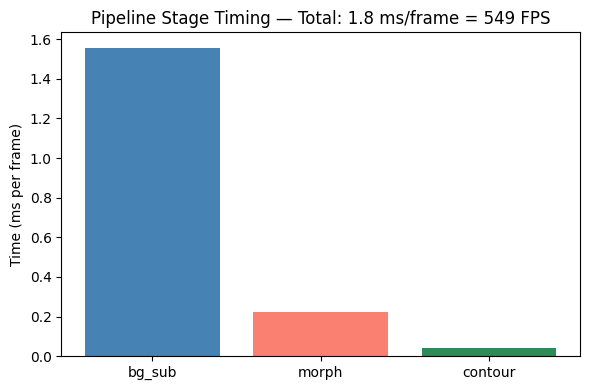

In [3]:
import cv2, numpy as np, time
import matplotlib.pyplot as plt

# ── Profile the pipeline on synthetic frames ───────────────────────────────

def make_frame(idx, h=240, w=400):
    frame = np.ones((h, w, 3), dtype=np.uint8) * 85
    frame[160:h, :] = (60,60,60)
    if 20 <= idx < 100:
        x = (idx-20)*5
        cv2.rectangle(frame, (x,75),(x+70,115),(180,100,60),-1)
    return frame

bg_sub = cv2.createBackgroundSubtractorMOG2(history=200, varThreshold=50, detectShadows=True)
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(5,5))

for i in range(30): bg_sub.apply(make_frame(0))

N = 200
times = {'bg_sub':[], 'morph':[], 'contour':[]}

for i in range(N):
    frame = make_frame(20 + i % 80)

    t0 = time.perf_counter()
    raw = bg_sub.apply(frame)
    t1 = time.perf_counter()

    _, fg = cv2.threshold(raw, 200, 255, cv2.THRESH_BINARY)
    fg = cv2.morphologyEx(fg, cv2.MORPH_OPEN,  kernel)
    fg = cv2.morphologyEx(fg, cv2.MORPH_CLOSE, kernel)
    fg = cv2.dilate(fg, kernel, iterations=2)
    t2 = time.perf_counter()

    cnts, _ = cv2.findContours(fg, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    t3 = time.perf_counter()

    times['bg_sub'].append((t1-t0)*1000)
    times['morph'].append( (t2-t1)*1000)
    times['contour'].append((t3-t2)*1000)

stages = list(times.keys())
means  = [np.mean(times[s]) for s in stages]
total  = sum(means)
fps    = 1000 / total

print(f'Pipeline profiling ({N} frames):')
print()
print(f'{"Stage":<15} {"Mean (ms)":<14} {"% of total"}')
print('-' * 40)
for s, m in zip(stages, means):
    print(f'{s:<15} {m:<14.2f} {m/total*100:.1f}%')
print(f'{"TOTAL":<15} {total:<14.2f}')
print(f'Estimated FPS: {fps:.0f}')

plt.figure(figsize=(6,4))
plt.bar(stages, means, color=['steelblue','salmon','seagreen'])
plt.ylabel('Time (ms per frame)')
plt.title(f'Pipeline Stage Timing — Total: {total:.1f} ms/frame = {fps:.0f} FPS')
plt.tight_layout()
plt.savefig('pipeline_profiling.png', dpi=100)
plt.show()

---
# What I Learned

I learned how to systematically test and improve a computer vision pipeline.

I learned that tuning is not guesswork. Each parameter has a specific effect and you change them
one at a time while watching the output. The varThreshold in MOG2 is the most important one:
if you set it too low you get lots of shadow and noise detections, too high and you miss small vehicles.

I learned about the main edge cases that break a vehicle counter:
shadows look like extra vehicles, two vehicles touching merge into one blob causing undercounting,
stopped vehicles slowly disappear into the background model,
and camera shake makes the whole frame look like motion.
Each of these has a specific fix at a specific stage of the pipeline.

I learned how to handle touching vehicles by using the blob area.
If a blob is unusually large, I estimate that it contains multiple vehicles by dividing its area
by the expected single-vehicle area. This is a simple heuristic but works well in practice.

I learned how to profile the pipeline to measure how fast each stage runs.
By timing background subtraction, morphology, and contour detection separately, I can find the
bottleneck and decide whether to simplify it or resize the input frame to improve FPS.